In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import sys
ROOT_PATH = "/content/drive/MyDrive/chiliSummerProject/src"
print(os.listdir(ROOT_PATH))
sys.path.append(ROOT_PATH)

['helper.py', 'data_exploration.ipynb', 'skel_cap_ipmg_map_logic.ipynb', 'model_exploration.ipynb', 'evaluation.ipynb', 'model_eval.ipynb', '__pycache__', 'logs', 'generate_data.ipynb', 'my_helpers.py', 'define_model.py', 'model_scratch.ipynb']


In [32]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [33]:
import numpy as np
import pandas as pd
import glob
from helper import *
from define_model import *
from my_helpers import *
import pprint as p
from sklearn.model_selection import train_test_split
from itertools import zip_longest
from tensorflow.keras.optimizers import Adam
from keras.callbacks import EarlyStopping
from keras.callbacks import ReduceLROnPlateau
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.utils import shuffle
from sklearn.metrics import f1_score


In [34]:
p.pprint(tf.test.is_built_with_cuda())
print('*'*50)
p.pprint(tf.config.list_physical_devices('GPU'))
print('*'*50)
p.pprint(tf.test.gpu_device_name())

True
**************************************************
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
**************************************************
'/device:GPU:0'


2023-08-21 14:18:38.601196: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:936] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2023-08-21 14:18:38.604153: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:936] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2023-08-21 14:18:38.604740: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:936] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2023-08-21 14:18:38.611829: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:936] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2023-08-21 14:18:38.612169: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:936] successful NUMA node read from S

In [35]:
drive = 0 # 1 if on google drive, 0 if not
data_dir = "/content/drive/MyDrive/chiliSummerProject/data/" if drive else "../data/"
model_path = "/content/drive/MyDrive/chiliSummerProject/models/" if drive else "../models/"
chili_models = model_path + "chili_models/"
identifier_eth = "TouchPose_crossGestures"
data_path_eth = data_dir + "eth_data/"
data_path_chili= data_dir + "processed/native_mapped/"
#set random seeds
np.random.seed(42)
tf.random.set_seed(42)

In [36]:
files = glob.glob(data_path_chili+'*.pkl')
files.remove(data_path_chili+'day3003.pkl')
chili_data = pd.concat([pd.read_pickle(fp) for fp in files], ignore_index=True)
chili_data['skeleton']= chili_data['skeleton'].apply(lambda x : x.astype(np.float32))
max_skel = np.max(chili_data['skeleton'].apply(lambda x : np.max(x)))
max_cap = np.max(chili_data['cap_img'].apply(lambda x : np.max(x)))
#chili_data['skeleton']= chili_data['skeleton'].apply(lambda x : x/max_skel)
chili_data['cap_img']= chili_data['cap_img'].apply(lambda x : x/max_cap)
print(chili_data.Timestamp.is_unique)
#chili_data.set_index('Timestamp', inplace=True)
#chili_data.sort_index(inplace=True)
print(len(chili_data))
chili_data.head()

True
82884


,Timestamp,skeleton,ScanSizeX,ScanSizeY,trial,gesture,subject,day,cap_img
0,1.679995e+12,"[[-236.0, 306.0, 164.0], [-234.0, 288.0, 137.0...",72,41,1,DQ,1,2803,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."
1,1.679995e+12,"[[-236.0, 307.0, 164.0], [-234.0, 288.0, 137.0...",72,41,1,DQ,1,2803,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."
2,1.679995e+12,"[[-236.0, 307.0, 163.0], [-234.0, 288.0, 137.0...",72,41,1,DQ,1,2803,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."
3,1.679995e+12,"[[-235.0, 307.0, 163.0], [-234.0, 287.0, 136.0...",72,41,1,DQ,1,2803,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."
4,1.679995e+12,"[[-235.0, 306.0, 162.0], [-234.0, 286.0, 136.0...",72,41,1,DQ,1,2803,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."


: 

In [6]:
chili_data.subject.value_counts()

subject
24    10545
27     6814
33     5752
11     4046
25     2788
2      2206
10     1263
32     1206
12     1195
22     1143
28      561
35      411
5       295
29      183
1         9
34        9
Name: count, dtype: int64

# Stratified train test split with shuffle from sklearn

In [ ]:
#TODO IN THIS TRAINING
#add np.seed, shuffle data for training done
#Split data into train and test sets done
#TODO CROSS TRAINING
# first cross subject
# 0.8 f each trial as tr test on 0.2
# cross gesture
# ADD GESTURE label-
# chec why we removed so much samples (maybe drift in timestamp)
model = load_model(chili_models+'partialModels/'+'partial_model.h5')
train, test_valid = train_test_split(chili_data, test_size=0.2, random_state=42, shuffle=True, stratify = chili_data['gesture'])
valid, test = train_test_split(test_valid, test_size=0.5, random_state=42, shuffle=True, stratify = test_valid['gesture'])

X_train, y_train = data_load(train)
X_valid, y_valid = data_load(valid)
X_test, y_test = data_load(test)

optimizer = Adam(learning_rate=0.01)
early_stop = EarlyStopping(monitor='val_loss', patience=30, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor= 0.5, patience = 10, min_lr=1e-7)
# Compile model
model.compile(optimizer=optimizer, loss=custom_loss, metrics=[end_point_error, auc_pck])

# Train model
history = model.fit(X_train, y_train, validation_data=(X_valid, y_valid), epochs=300, batch_size=32, callbacks=[reduce_lr, early_stop])
model.save(model_path+'chili_adaptive10_early30_300_161_epochs_lr0.001_second.h5')

NameError: ignored

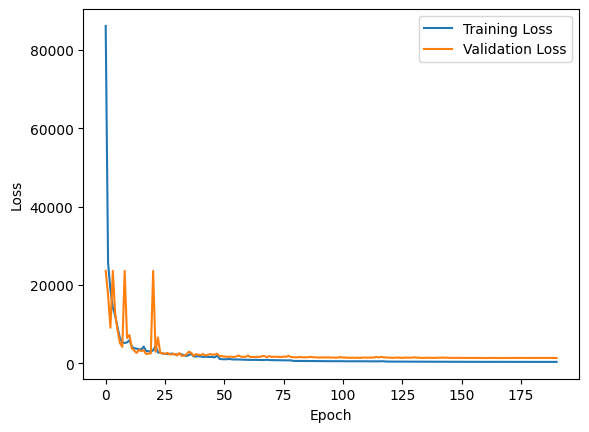

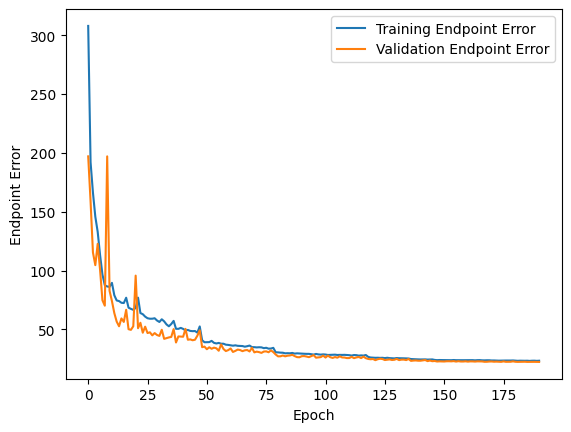

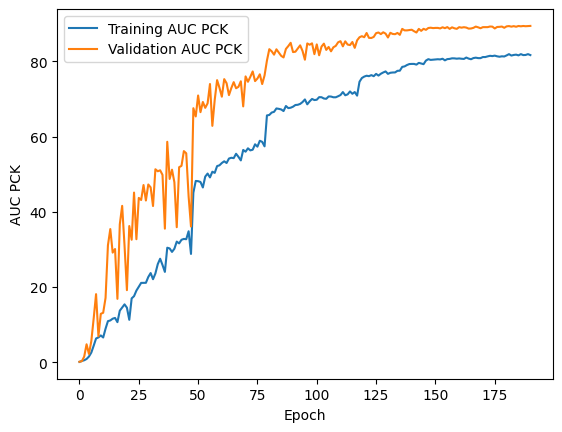

In [ ]:
# Clip outlier values
max_loss_value = sorted(history.history['val_loss'])[-4] # Set a maximum value to clip outliers
max_epe_value = sorted(history.history['val_end_point_error'])[-2]
clipped_val_loss = [min(loss, max_loss_value) for loss in history.history['val_loss']]
clipped_val_endpoint_error = [min(error, max_epe_value) for error in history.history['val_end_point_error']]

# Plot clipped validation loss
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(clipped_val_loss, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Plot clipped validation endpoint error
plt.plot(history.history['end_point_error'], label='Training Endpoint Error')
plt.plot(clipped_val_endpoint_error, label='Validation Endpoint Error')
plt.xlabel('Epoch')
plt.ylabel('Endpoint Error')
plt.legend()
plt.show()


plt.plot(history.history
['auc_pck'], label='Training AUC PCK')
plt.plot(history.history['val_auc_pck'], label='Validation AUC PCK')
plt.xlabel('Epoch')
plt.ylabel('AUC PCK')
plt.legend()
plt.show()

# Cross validation gesture model

In [ ]:
for g in chili_data.gesture.unique() :
    model = load_model(chili_models+'partialModels/multi_model_partial.h5')

    train = shuffle(chili_data[chili_data.gesture!=g].copy(),random_state=42)
    test = shuffle(chili_data[chili_data.gesture==g].copy(),random_state=42)
    train.gesture = pd.Categorical(train.gesture, categories=chili_data.gesture.unique())
    test.gesture = pd.Categorical(test.gesture, categories=chili_data.gesture.unique())
    X_train, y_train_skeleton, y_train_gesture = data_multiload(train)
    X_test, y_test_skeleton, y_test_gesture = data_multiload(test)


    optimizer = Adam(learning_rate=0.01)
    early_stop = EarlyStopping(monitor='val_loss', patience=30, restore_best_weights=True)
    reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor= 0.5, patience = 10, min_lr=1e-7)
    beta = 0.2
    model.compile(optimizer=optimizer, loss={'skeleton': skeleton_loss, 'gesture': 'categorical_crossentropy'},
                  loss_weights={'skeleton': 1.0, 'gesture': beta},
                  metrics={'skeleton': [end_point_error, auc_pck], 'gesture': 'accuracy'})

    history = model.fit(X_train, {'skeleton': y_train_skeleton, 'gesture': y_train_gesture},validation_split=0.2,
                         epochs=300, batch_size=32, callbacks=[early_stop,reduce_lr])

    model.save(chili_models+'/crossGesture/crossmulti_beta0.2_'+str(left_out)+'.h5')

# Cross validation subject model

In [ ]:
for s in chili_data.subject.unique() :
    model = load_model(chili_models+'partialModels/multi_model_partial.h5')

    train = shuffle(chili_data[chili_data.subject!=s].copy(),random_state=42)
    test = shuffle(chili_data[chili_data.subject==s].copy(),random_state=42)
    train.gesture = pd.Categorical(train.gesture, categories=chili_data.gesture.unique())
    test.gesture = pd.Categorical(test.gesture, categories=chili_data.gesture.unique())
    X_train, y_train_skeleton, y_train_gesture = data_multiload(train)
    X_test, y_test_skeleton, y_test_gesture = data_multiload(test)


    optimizer = Adam(learning_rate=0.01)
    early_stop = EarlyStopping(monitor='val_loss', patience=30, restore_best_weights=True)
    reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor= 0.5, patience = 10, min_lr=1e-7)
    beta = 0.2
    model.compile(optimizer=optimizer, loss={'skeleton': skeleton_loss, 'gesture': 'categorical_crossentropy'},
                  loss_weights={'skeleton': 1.0, 'gesture': beta},
                  metrics={'skeleton': [end_point_error, auc_pck], 'gesture': 'accuracy'})

    history = model.fit(X_train, {'skeleton': y_train_skeleton, 'gesture': y_train_gesture},validation_split=0.2,
                         epochs=300, batch_size=32, callbacks=[early_stop,reduce_lr])

    model.save(chili_models+'/crossSubject/crossmulti_beta0.2_'+str(left_out)+'.h5')

In [ ]:
for s in [2,10,11,12,22,24,25] :
    model = load_model(chili_models+'/crossSubject/crossmulti_beta0.2_'+str(s)+'.h5',compile=False)
    print('test set on subject '+str(s))
    test = shuffle(chili_data[chili_data.subject==s].copy(),random_state=42)
    test.gesture = pd.Categorical(test.gesture, categories=chili_data.gesture.unique())
    X_test, y_test_skeleton, y_test_gesture = data_multiload(test)
    y_out_gesture, y_out_skeleton = model.predict(X_test, batch_size=32)
    skeleton_error = np.mean(abs(y_test_skeleton - y_out_skeleton))
    auc = auc_pck(y_test_skeleton,y_out_skeleton).numpy()
    epe = end_point_error(y_test_skeleton,y_out_skeleton).numpy()
    y_out_gesture_labels = np.argmax(y_out_gesture, axis=1)
    y_test_gesture_labels = np.argmax(y_test_gesture, axis=1)
    gesture_accuracy = np.mean(y_out_gesture_labels == y_test_gesture_labels)
    gesture_f1_score = f1_score(y_test_gesture_labels, y_out_gesture_labels, average='weighted')
    print("Gesture Accuracy: ", gesture_accuracy)
    print("Gesture F1 Score: ", gesture_f1_score)
    print("Mean Error: ",skeleton_error)
    print("AucPCK : ", auc)
    print("End point error ", epe)
    print('*'*50)

test set on subject 2
69/69 [==============================] - 16s 222ms/step
Gesture Accuracy:  0.43789664551223934
Gesture F1 Score:  0.44540846585315597
Mean Error:  30.438606
AucPCK :  [0.         0.         0.         0.         0.04533092 0.09066183
 0.13599275]
End point error  282.9811
**************************************************
test set on subject 10
40/40 [==============================] - 7s 170ms/step
Gesture Accuracy:  0.517814726840855
Gesture F1 Score:  0.6823161189358372
Mean Error:  24.49932
AucPCK :  [0. 0. 0. 0. 0. 0. 0.]
End point error  244.18512
**************************************************
test set on subject 11
127/127 [==============================] - 28s 220ms/step
Gesture Accuracy:  0.4003954522985665
Gesture F1 Score:  0.42727687760811583
Mean Error:  19.044207
AucPCK :  [0.         0.         0.         0.07414731 0.56846267 1.4582304
 2.7187345 ]
End point error  198.99962
**************************************************
test set on subject 

# Train test split multi model

In [ ]:
model = load_model(chili_models+'partialModels/multi_model_partial.h5')
train, test_valid = train_test_split(chili_data, test_size=0.2, random_state=42, shuffle=True, stratify = chili_data['gesture'])
valid, test = train_test_split(test_valid, test_size=0.5, random_state=42, shuffle=True, stratify = test_valid['gesture'])

X_train, y_train_skeleton, y_train_gesture = data_multiload(train)
X_valid, y_valid_skeleton, y_valid_gesture = data_multiload(valid)
X_test, y_test_skeleton, y_test_gesture = data_multiload(test)


optimizer = Adam(learning_rate=0.01)
early_stop = EarlyStopping(monitor='val_loss', patience=30, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor= 0.5, patience = 10, min_lr=1e-7)
beta = 0.2

model.compile(optimizer=optimizer, loss={'skeleton': skeleton_loss, 'gesture': 'categorical_crossentropy'},
              loss_weights={'skeleton': 1.0, 'gesture': beta},
              metrics={'skeleton': [end_point_error, auc_pck], 'gesture': 'accuracy'})

history = model.fit(X_train, {'skeleton': y_train_skeleton, 'gesture': y_train_gesture},
                    validation_data=(X_valid, {'skeleton': y_valid_skeleton, 'gesture': y_valid_gesture}),
                    epochs=300, batch_size=32, callbacks=[reduce_lr, early_stop])

model.save(chili_models+'tr_test_split_multi_beta0.2.h5')

Epoch 1/300
961/961 [==============================] - 32s 16ms/step - loss: 71617.8047 - gesture_loss: 2.5078 - skeleton_loss: 71616.8750 - gesture_accuracy: 0.3470 - skeleton_end_point_error: 286.0084 - skeleton_auc_pck: 0.0776 - val_loss: 23313.9180 - val_gesture_loss: 2.1904 - val_skeleton_loss: 23313.0410 - val_gesture_accuracy: 0.4218 - val_skeleton_end_point_error: 176.5306 - val_skeleton_auc_pck: 0.3616 - lr: 0.0100
Epoch 2/300
961/961 [==============================] - 13s 14ms/step - loss: 25321.1328 - gesture_loss: 1.8799 - skeleton_loss: 25320.3516 - gesture_accuracy: 0.3906 - skeleton_end_point_error: 193.0047 - skeleton_auc_pck: 0.2829 - val_loss: 150285040.0000 - val_gesture_loss: 1.7892 - val_skeleton_loss: 150285040.0000 - val_gesture_accuracy: 0.4614 - val_skeleton_end_point_error: 398.3798 - val_skeleton_auc_pck: 2.2395 - lr: 0.0100
Epoch 3/300
961/961 [==============================] - 13s 13ms/step - loss: 17287.6855 - gesture_loss: 1.5371 - skeleton_loss: 17287.09

# 80/20 each trial

In [ ]:
model = load_model(chili_models+'partialModels/multi_model_partial.h5')

train = shuffle(chili_data.groupby(['subject','trial']).apply(lambda x: x.head(round(0.8*len(x)))).reset_index(drop=True),random_state=42)
test = shuffle(chili_data.groupby(['subject','trial']).apply(lambda x: x.tail(round(0.2*len(x)))).reset_index(drop=True),random_state=42)
train.gesture = pd.Categorical(train.gesture, categories=chili_data.gesture.unique())
test.gesture = pd.Categorical(test.gesture, categories=chili_data.gesture.unique())
X_train, y_train_skeleton, y_train_gesture = data_multiload(train)
X_test, y_test_skeleton, y_test_gesture = data_multiload(test)

optimizer = Adam(learning_rate=0.001)
early_stop = EarlyStopping(monitor='val_loss', patience=30, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor= 0.5, patience = 10, min_lr=1e-7)
beta = 0.2
model.compile(optimizer=optimizer, loss={'skeleton': skeleton_loss, 'gesture': 'categorical_crossentropy'},
                  loss_weights={'skeleton': 1.0, 'gesture': beta},
                  metrics={'skeleton': [end_point_error, auc_pck], 'gesture': 'accuracy'})

history = model.fit(X_train, {'skeleton': y_train_skeleton, 'gesture': y_train_gesture},validation_split=0.2,
                         epochs=300, batch_size=32, callbacks=[early_stop,reduce_lr])

model.save(chili_models+'80trial_beta0.2.h5')

Epoch 1/300
769/769 [==============================] - 22s 16ms/step - loss: 226806.5625 - gesture_loss: 1.8595 - skeleton_loss: 226806.2344 - gesture_accuracy: 0.3178 - skeleton_end_point_error: 495.7207 - skeleton_auc_pck: 0.0279 - val_loss: 33952.3711 - val_gesture_loss: 1.7532 - val_skeleton_loss: 33952.0234 - val_gesture_accuracy: 0.3975 - val_skeleton_end_point_error: 215.0969 - val_skeleton_auc_pck: 0.1457 - lr: 0.0010
Epoch 2/300
769/769 [==============================] - 11s 15ms/step - loss: 48931.8945 - gesture_loss: 1.9743 - skeleton_loss: 48931.4141 - gesture_accuracy: 0.3177 - skeleton_end_point_error: 270.3382 - skeleton_auc_pck: 0.0441 - val_loss: 25392.0371 - val_gesture_loss: 1.7127 - val_skeleton_loss: 25391.6875 - val_gesture_accuracy: 0.3182 - val_skeleton_end_point_error: 184.9713 - val_skeleton_auc_pck: 0.0948 - lr: 0.0010
Epoch 3/300
769/769 [==============================] - 11s 14ms/step - loss: 33898.3555 - gesture_loss: 1.8608 - skeleton_loss: 33898.0195 - g

# Model from Scratch

In [ ]:
model = create_SkeletonModel(41, 72, 1)

In [ ]:
X,y = data_splits(chili_data)

# Split data into train and test sets
X_train, X_rem, y_train, y_rem = train_test_split(X,y, test_size=0.2, random_state=42)

# Now since we want the valid and test size to be equal (10% each of overall data).
# we have to define valid_size=0.5 (that is 50% of remaining data)
test_size = 0.5
X_valid, X_test, y_valid, y_test = train_test_split(X_rem,y_rem, test_size=0.5, random_state=42)

optimizer = Adam(learning_rate=0.01)
early_stop = EarlyStopping(monitor='val_loss', patience=30, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor= 0.5, patience = 10, min_lr=1e-7)
# Compile model
model.compile(optimizer=optimizer, loss=custom_loss, metrics=[end_point_error, auc_pck])

# Train model
history = model.fit(X_train, y_train, validation_data=(X_valid, y_valid), epochs=300, batch_size=32, callbacks=[reduce_lr, early_stop])

Epoch 1/300
601/601 [==============================] - 12s 12ms/step - loss: 91617.3281 - end_point_error: 305.3602 - auc_pck: 0.0825 - val_loss: 1435016064.0000 - val_end_point_error: 2467.6228 - val_auc_pck: 0.0235 - lr: 0.0100
Epoch 2/300
601/601 [==============================] - 9s 14ms/step - loss: 38317.9258 - end_point_error: 225.8383 - auc_pck: 0.1909 - val_loss: 25315.9824 - val_end_point_error: 179.0437 - val_auc_pck: 0.0059 - lr: 0.0100
Epoch 3/300
601/601 [==============================] - 8s 13ms/step - loss: 26996.5312 - end_point_error: 191.6779 - auc_pck: 0.4264 - val_loss: 21001.4609 - val_end_point_error: 160.7907 - val_auc_pck: 0.0705 - lr: 0.0100
Epoch 4/300
601/601 [==============================] - 7s 11ms/step - loss: 20497.7949 - end_point_error: 169.5250 - auc_pck: 0.6448 - val_loss: 13963.6484 - val_end_point_error: 136.8766 - val_auc_pck: 0.1057 - lr: 0.0100
Epoch 5/300
601/601 [==============================] - 7s 11ms/step - loss: 15843.7188 - end_point_er

# Load partially model

In [ ]:
model_eth = get_eth_model('TouchPose_crossGestures',65,model_path)
model = create_skeleton_gesture_model(41, 72, 1)

In [ ]:
print(model_eth.input)
print(model_eth.output)

KerasTensor(type_spec=TensorSpec(shape=(None, 41, 72, 1), dtype=tf.float32, name='input_25'), name='input_25', description="created by layer 'input_25'")
KerasTensor(type_spec=TensorSpec(shape=(None, 41, 72, 1), dtype=tf.float32, name=None), name='regression_depth/BiasAdd:0', description="created by layer 'regression_depth'")


In [ ]:
print(model.input)
print(model.output)

KerasTensor(type_spec=TensorSpec(shape=(None, 41, 72, 1), dtype=tf.float32, name='input_2'), name='input_2', description="created by layer 'input_2'")
KerasTensor(type_spec=TensorSpec(shape=(None, 63), dtype=tf.float32, name=None), name='regression/BiasAdd:0', description="created by layer 'regression'")


In [ ]:
print(len(model.layers))

19


In [ ]:
print(len(model_eth.layers))

26


In [ ]:
match = []
for depth_layer, skel_layer, pos in zip(model_eth.layers,model.layers,range(len(model.layers))):
    match.append((depth_layer.name , skel_layer.name, pos ))
match

[('input_25', 'input_1', 0),
 ('conv2d_336', 'conv2d', 1),
 ('conv2d_337', 'conv2d_1', 2),
 ('max_pooling2d_72', 'max_pooling2d', 3),
 ('conv2d_338', 'conv2d_2', 4),
 ('conv2d_339', 'conv2d_3', 5),
 ('max_pooling2d_73', 'max_pooling2d_1', 6),
 ('conv2d_340', 'conv2d_4', 7),
 ('conv2d_341', 'conv2d_5', 8),
 ('max_pooling2d_74', 'max_pooling2d_2', 9),
 ('conv2d_342', 'conv2d_6', 10),
 ('conv2d_343', 'flatten', 11),
 ('up_sampling2d_72', 'dense', 12),
 ('concatenate_72', 'activation', 13),
 ('conv2d_344', 'batch_normalization', 14),
 ('conv2d_345', 'dropout', 15),
 ('up_sampling2d_73', 'dense_1', 16),
 ('concatenate_73', 'gesture', 17),
 ('conv2d_346', 'skeleton', 18)]

In [ ]:
match = [ (''.join([ xi for xi in x[0] if not (xi.isdigit() or xi== '_')]),''.join([ xi for xi in x[1] if not (xi.isdigit() or xi== '_')]),x[2]) for x in match]
match

[('input', 'input', 0),
 ('convd', 'convd', 1),
 ('convd', 'convd', 2),
 ('maxpoolingd', 'maxpoolingd', 3),
 ('convd', 'convd', 4),
 ('convd', 'convd', 5),
 ('maxpoolingd', 'maxpoolingd', 6),
 ('convd', 'convd', 7),
 ('convd', 'convd', 8),
 ('maxpoolingd', 'maxpoolingd', 9),
 ('convd', 'convd', 10),
 ('convd', 'flatten', 11),
 ('upsamplingd', 'dense', 12),
 ('concatenate', 'activation', 13),
 ('convd', 'batchnormalization', 14),
 ('convd', 'dropout', 15),
 ('upsamplingd', 'dense', 16),
 ('concatenate', 'gesture', 17),
 ('convd', 'skeleton', 18)]

In [ ]:
good_match = [x for x in match if x[0]==x[1]]
good_match

[('input', 'input', 0),
 ('convd', 'convd', 1),
 ('convd', 'convd', 2),
 ('maxpoolingd', 'maxpoolingd', 3),
 ('convd', 'convd', 4),
 ('convd', 'convd', 5),
 ('maxpoolingd', 'maxpoolingd', 6),
 ('convd', 'convd', 7),
 ('convd', 'convd', 8),
 ('maxpoolingd', 'maxpoolingd', 9),
 ('convd', 'convd', 10)]

In [ ]:
for i in range(len(good_match)):
    pos = match[i][2]
    model.layers[pos].set_weights(model_eth.layers[pos].get_weights())

In [ ]:
model.save(chili_models+'multi_model_partial.h5')

In [ ]:
X,y = data_splits(chili_data)

# Split data into train and test sets
X_train, X_rem, y_train, y_rem = train_test_split(X,y, test_size=0.2, random_state=42)

# Now we want the valid and test size to be equal (10% each of overall data).
test_size = 0.5
X_valid, X_test, y_valid, y_test = train_test_split(X_rem,y_rem, test_size=0.5)

# Define custom loss function

start = 20/max_skel
stop = 50/max_skel
step = 5/max_skel

def auc_pck_norm(y_true, y_pred):
    thresholds = np.arange(start, stop+step, step)  # Thresholds from 20 mm to 50 mm
    pck_values = []


    # Calculate the Euclidean distance between predicted and true joint coordinates
    distances = tf.sqrt(tf.reduce_sum(tf.square(y_true - y_pred), axis=-1))

    # Calculate the percentage of correct keypoints for each threshold
    for threshold in thresholds:
        correct_keypoints = tf.cast(distances < threshold, tf.float32)
        pck = tf.reduce_mean(correct_keypoints) * 100.0
        pck_values.append(pck)

    return tf.convert_to_tensor(pck_values, dtype=tf.float32)


optimizer = Adam(learning_rate=0.01)
# Compile model
model.compile(optimizer=optimizer, loss=custom_loss, metrics=[end_point_error, auc_pck_norm])

# Train model
history = model.fit(X_train, y_train, validation_data=(X_valid, y_valid), epochs=200, batch_size=32)


Epoch 1/200


TypeError: ignored

In [ ]:
model.save(model_path+'chili_normalized_200_epochs_lr0.001_decay5e-6.h5')